In [98]:
from pathlib import Path
import gzip
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [109]:
sns.set_theme(context="notebook", style="whitegrid")

In [ ]:
THRESHOLDS = [1, 2, 3, 4, 5, 6, 7, 8, 9] # tons
N_SAMPLES = 1

root = Path("../results/exp_1")
all_jsons = list(root.rglob("*.json.gz"))

hold_pcts = []
high_pcts = []
for threshold in THRESHOLDS:

    print(f"Using threshold of {threshold} tons...")
    total_holds = []
    total_highs, total_lows = 0, 0
    for file in all_jsons:
        with gzip.open(file, 'rt', encoding='utf-8') as f:
            aggregate_payload = json.load(f)

        for run in aggregate_payload["runs"]:
            high_types, low_types = [], []

            epsilons = run["sampled_inputs"]["epsilons"]
            het_costs = run["sampled_inputs"]["het_costs"]
            intermediaries = run["summary_no_pay"]["instance_snapshot"]["intermediaries"]

            # load data for low and high types
            for intermediary in intermediaries:
                intermediary_id = intermediary["id"]

                # get the intermediary parameters
                epsilon = epsilons[intermediary_id]
                sigma = het_costs[intermediary_id]
                n = intermediary["status_quo_quantity"] # n is expected hist. quantity

                # bucket ints into high or low types
                if n >= threshold:
                    high_types.append(sigma / epsilon)
                else:
                    low_types.append(sigma / (n + epsilon))

            total_highs += len(high_types)
            total_lows += len(low_types)

            if not high_types or not low_types:
                continue

            # sample and check if condition holds
            high_rhs = np.random.choice(high_types, size=N_SAMPLES, replace=True)
            low_lhs = np.random.choice(low_types, size=N_SAMPLES, replace=True)

            condition_holds = low_lhs <= high_rhs

            total_holds.extend(condition_holds)

    hold_pct = np.mean(total_holds)
    hold_pcts.append(hold_pct)
    high_pct = total_highs / (total_highs + total_lows)
    high_pcts.append(high_pct)

    print(f"% of ints that are high-types: {high_pct:.2%}")
    print(f"% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: {hold_pct:.2%}\n")

Using threshold of 1 tons...
% of ints that are high-types: 64.40%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 44.92%

Using threshold of 2 tons...
% of ints that are high-types: 47.08%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 48.49%

Using threshold of 3 tons...
% of ints that are high-types: 24.81%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 53.72%

Using threshold of 4 tons...
% of ints that are high-types: 14.25%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 52.75%

Using threshold of 5 tons...
% of ints that are high-types: 7.58%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 52.52%

Using threshold of 6 tons...
% of ints that are high-types: 3.29%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 59.66%

Using threshold of 7 tons...
% of ints that are high-types: 1.24%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 72.18%

Using threshold of 8 tons...
% of ints that are hig

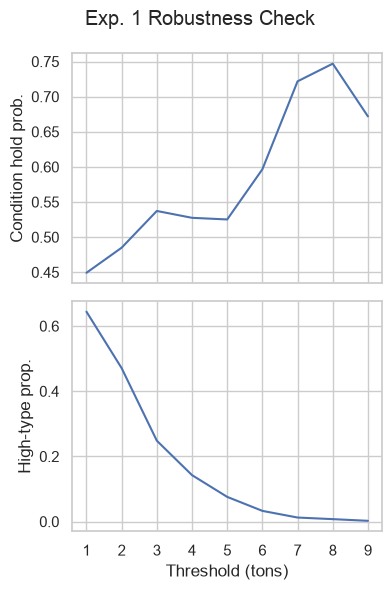

In [147]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(4, 6), sharex=True)

ax[0].plot(THRESHOLDS, hold_pcts)
ax[0].set_ylabel("Condition hold prob.")

ax[1].plot(THRESHOLDS, high_pcts)
ax[1].set_xlabel("Threshold (tons)")
ax[1].set_xticks(THRESHOLDS)
ax[1].set_ylabel("High-type prop.")

fig.suptitle("Exp. 1 Robustness Check")

plt.tight_layout()
plt.show()

In [154]:
THRESHOLDS = [1, 2, 3, 4, 5, 6, 7, 8, 9] # tons
N_SAMPLES = 1

root = Path("../results/exp_2")
all_jsons = list(root.rglob("*.json.gz"))

hold_pcts = []
high_pcts = []
for threshold in THRESHOLDS:

    print(f"Using threshold of {threshold} tons...")
    total_holds = []
    total_highs, total_lows = 0, 0
    for file in all_jsons:
        with gzip.open(file, 'rt', encoding='utf-8') as f:
            aggregate_payload = json.load(f)

        for run in aggregate_payload["runs"]:
            high_types, low_types = [], []

            epsilons = run["sampled_inputs"]["epsilons"]
            het_costs = run["sampled_inputs"]["het_costs"]
            intermediaries = run["summary_vanilla_no_pay"]["instance_snapshot"]["intermediaries"]

            # load data for low and high types
            for intermediary in intermediaries:
                intermediary_id = intermediary["id"]

                # get the intermediary parameters
                epsilon = epsilons[intermediary_id]
                sigma = het_costs[intermediary_id]
                n = intermediary["status_quo_quantity"] # n is expected hist. quantity

                # bucket ints into high and low types
                if n >= threshold:
                    if epsilon > 0:
                        high_types.append(sigma / epsilon)
                else:
                    if n + epsilon > 0:
                        low_types.append(sigma / (n + epsilon))

            total_highs += len(high_types)
            total_lows += len(low_types)

            if not high_types or not low_types:
                continue

            # sample and check if condition holds
            high_rhs = np.random.choice(high_types, size=N_SAMPLES, replace=True)
            low_lhs = np.random.choice(low_types, size=N_SAMPLES, replace=True)

            condition_holds = low_lhs <= high_rhs

            total_holds.extend(condition_holds)

    hold_pct = np.mean(total_holds)
    hold_pcts.append(hold_pct)

    high_pct = total_highs / (total_highs + total_lows)
    high_pcts.append(high_pct)

    print(f"% of ints that are high-types: {high_pct:.2%}")
    print(f"% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: {hold_pct:.2%}\n")

Using threshold of 1 tons...
% of ints that are high-types: 64.27%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 42.30%

Using threshold of 2 tons...
% of ints that are high-types: 46.12%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 46.80%

Using threshold of 3 tons...
% of ints that are high-types: 23.70%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 47.50%

Using threshold of 4 tons...
% of ints that are high-types: 13.47%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 47.94%

Using threshold of 5 tons...
% of ints that are high-types: 7.07%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 49.88%

Using threshold of 6 tons...
% of ints that are high-types: 3.05%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 58.71%

Using threshold of 7 tons...
% of ints that are high-types: 1.16%
% of instances where sigma_l/(n_l + eps_l) <= sigma_h/eps_h: 68.71%

Using threshold of 8 tons...
% of ints that are hig

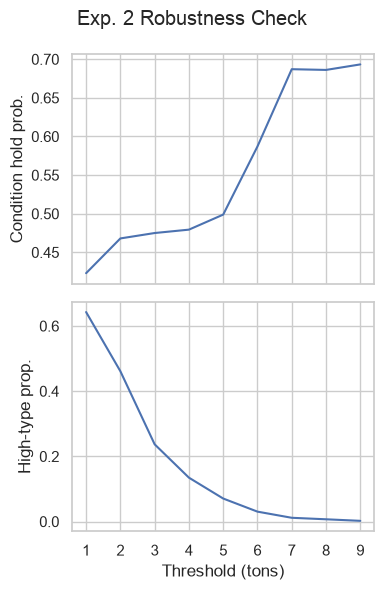

In [155]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(4, 6), sharex=True)

ax[0].plot(THRESHOLDS, hold_pcts)
ax[0].set_ylabel("Condition hold prob.")

ax[1].plot(THRESHOLDS, high_pcts)
ax[1].set_xlabel("Threshold (tons)")
ax[1].set_xticks(THRESHOLDS)
ax[1].set_ylabel("High-type prop.")

fig.suptitle("Exp. 2 Robustness Check")

plt.tight_layout()
plt.show()